- Cargar imagen y librerías

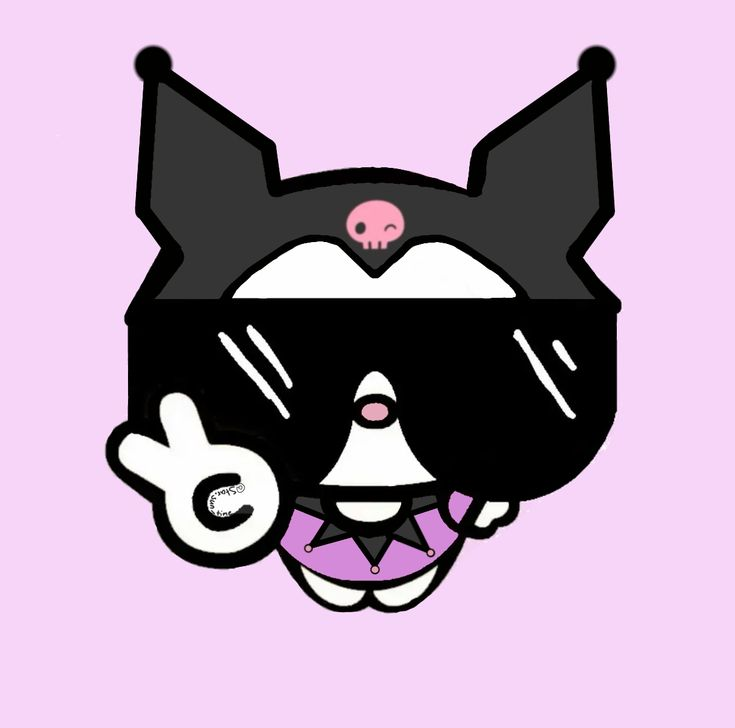

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

imagen = cv2.imread('convoluciones.jpg', cv2.IMREAD_COLOR)

cv2_imshow(imagen)

- Función para agregar ruido Salt&Pepper

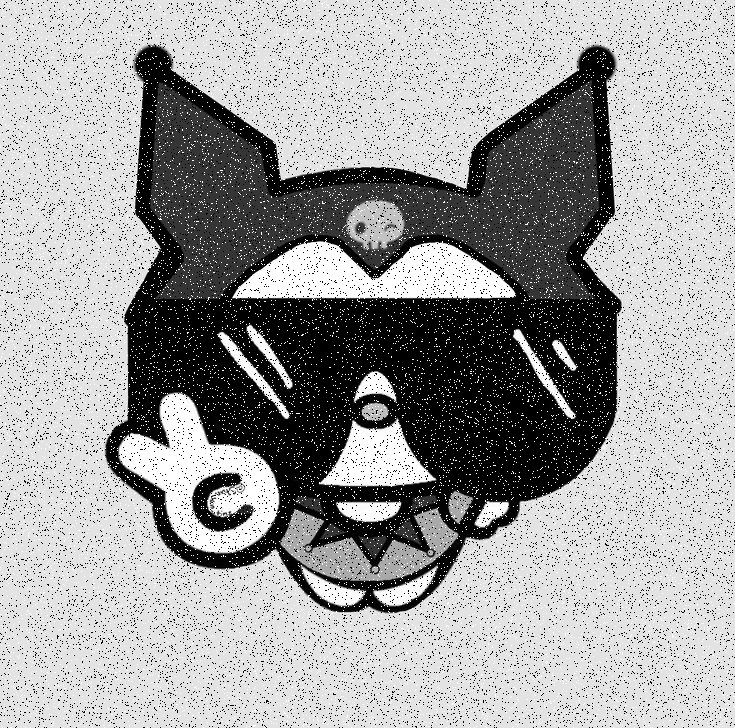

In [ ]:
def salt_pepper(imagen, prob):
  ruido = imagen.copy()
  ruido = cv2.cvtColor(ruido, cv2.COLOR_BGR2GRAY)

  rand = np.random.rand(*imagen.shape[:2])
  ruido[rand < prob/2] = 0
  ruido[rand > 1 - prob/2] = 255

  return ruido

imagen_ruido = salt_pepper(imagen, 0.1)

cv2_imshow(imagen_ruido)

- Diccionario de kernels

In [ ]:
import numpy as np

kernels = {
  "media": np.ones((3,3), dtype=np.float32) / 9,

  "media5": np.ones((5,5), dtype=np.float32) / 25,

  "gaussiano": np.array([
      [1, 2,  1],
      [2, 4,  2],
      [1, 2,  1]
  ], dtype=np.float32) / 16,

  "gaussiano5": np.array([
      [1, 4,  6,  4,  1],
      [4, 16, 24, 16, 4],
      [6, 24, 36, 24, 6],
      [4, 16, 24, 16, 4],
      [1, 4,  6,  4,  1]
  ], dtype=np.float32) / 256,

  "box_pesado": np.array([
      [1, 1,  1],
      [1, 2,  1],
      [1, 1, 1]
  ], dtype=np.float32) / 10
}

- Función para hacer convolusion con un kernel específico y comparar con la función de OpenCV

Sin OpenCV


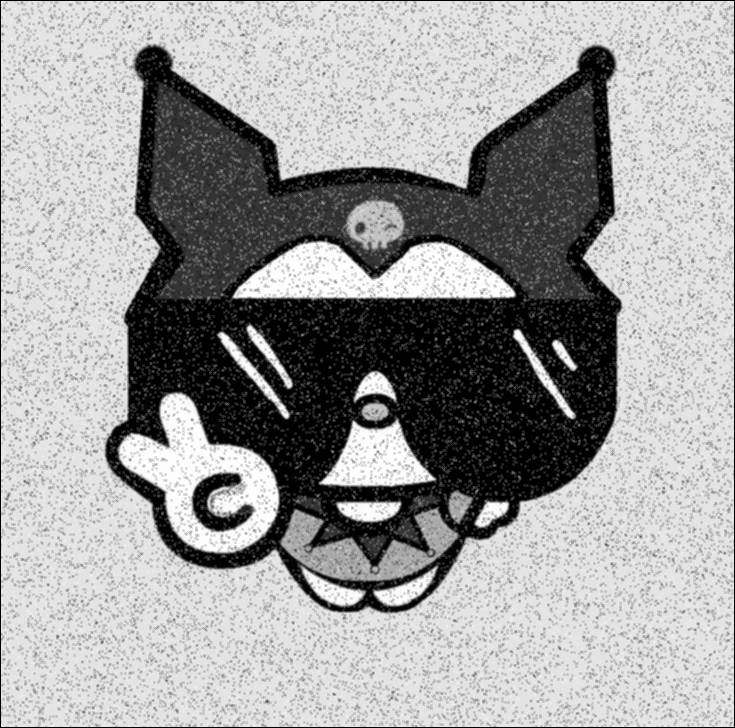

Con OpenCV


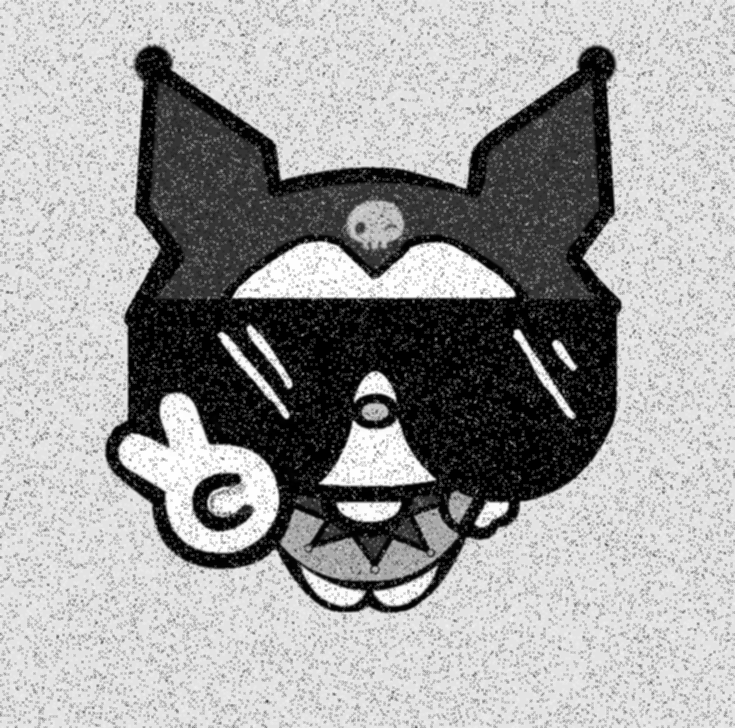

In [ ]:
import numpy as np

def convolucion(imagen, kernel):
    alto, ancho = imagen.shape
    k = kernel.shape[0] // 2

    salida = np.zeros_like(imagen, dtype=np.float32)

    for y in range(k, alto - k):
        for x in range(k, ancho - k):

            suma = 0.0
            for i in range(-k, k + 1):
                for j in range(-k, k + 1):
                    suma += imagen[y + i, x + j] * kernel[i + k, j + k]

            salida[y, x] = suma

    return salida

kernel = kernels["box_pesado"]
img_convolusionada = convolucion(imagen_ruido, kernel)
img_convolusionada = np.clip(img_convolusionada, 0, 255).astype(np.uint8)
print("Sin OpenCV")
cv2_imshow(img_convolusionada)

comparar_funcion = cv2.filter2D(imagen_ruido, -1, kernel)
print("Con OpenCV")
cv2_imshow(comparar_funcion)

- Funciones propias de OpenCV

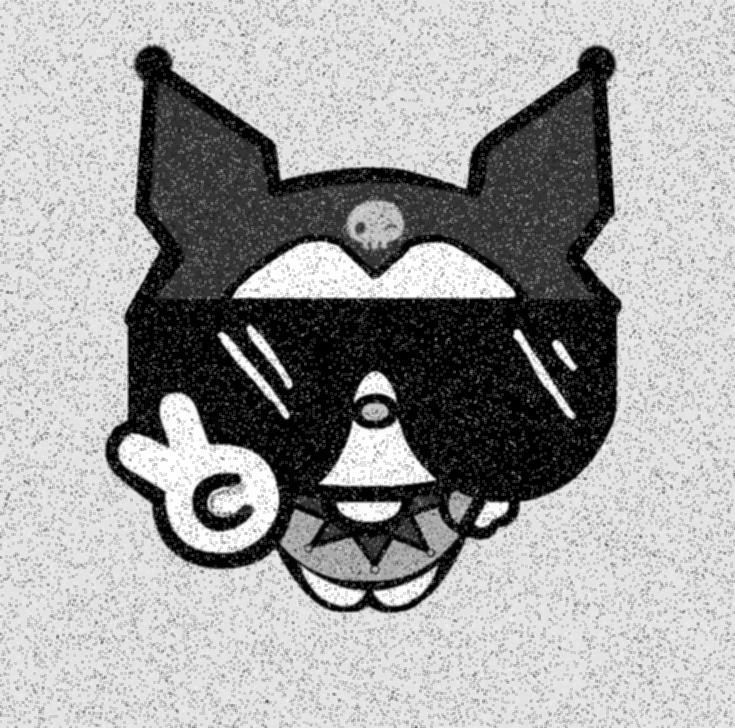

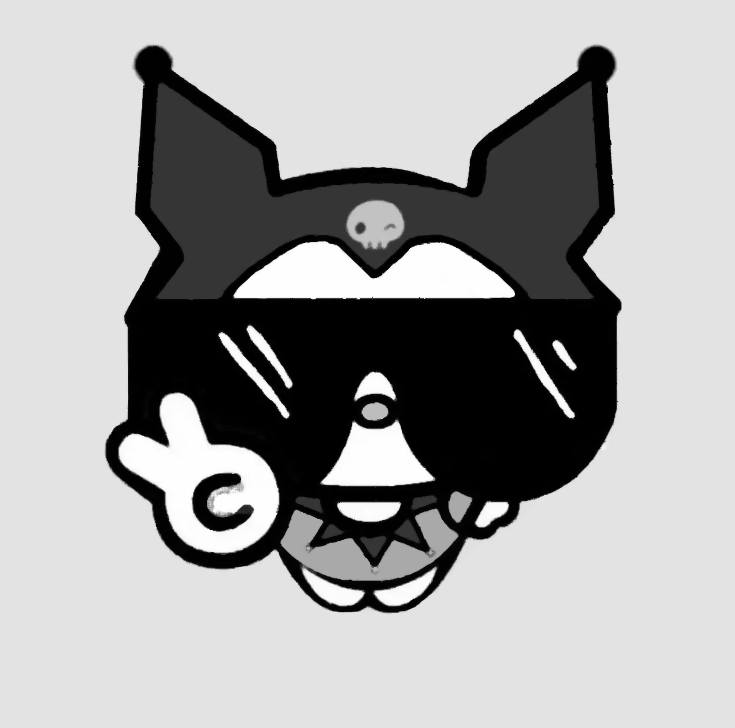

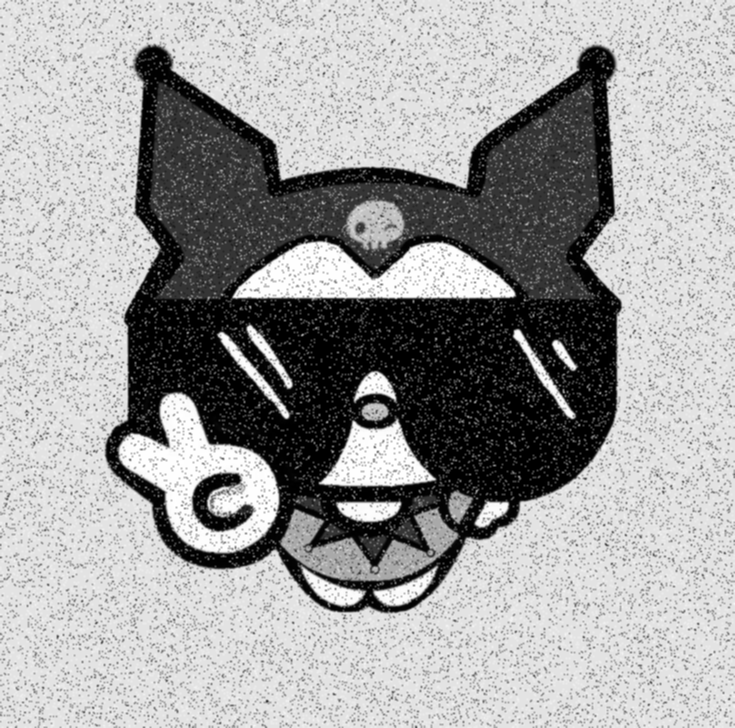

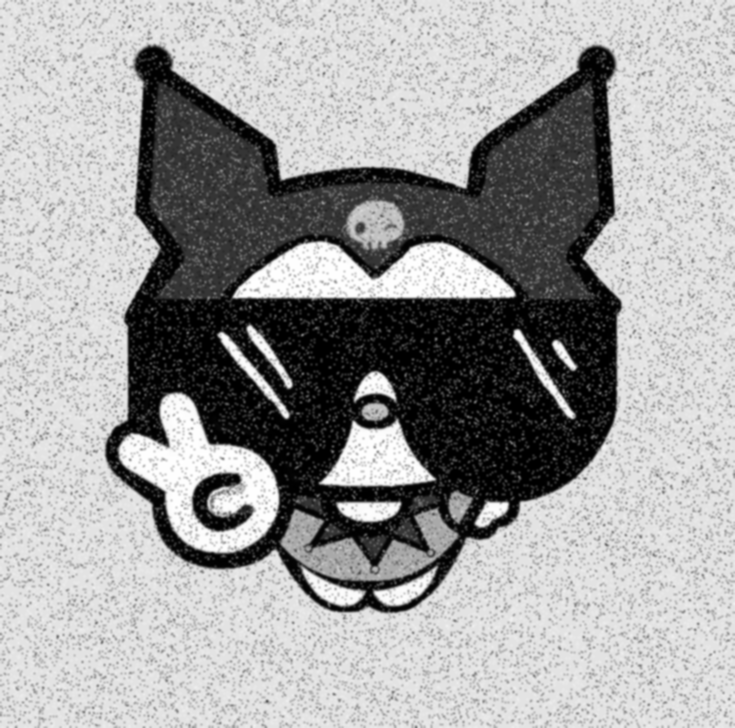

In [ ]:
img_media = cv2.blur(imagen_ruido, (3,3))
cv2_imshow(img_media)

img_media5 = cv2.medianBlur(imagen_ruido, 5)
cv2_imshow(img_media5)

img_gaussiano = cv2.GaussianBlur(imagen_ruido, (3,3), 0)
cv2_imshow(img_gaussiano)

img_gaussiano5 = cv2.GaussianBlur(imagen_ruido, (5,5), 0)
cv2_imshow(img_gaussiano5)

### Análisis

- **Impacto del ruido sal y pimienta**: Con una probabilidad de ruido de 0.1, la imagen se vuelve visiblemente degradada. Aproximadamente a partir de una probabilidad de 0.7 la imagen se ve muy diferente.

- **Función de convolución propia vs. cv2.filter2D**: Ambas funciones tienen el mismo efecto en la imagen ruidosa, una salida con ruido reducido pero con un grado de difuminado.

- **Kernels 3x3**: Los kernels de media y gaussiano muestran una capacidad limitada para eliminar completamente el ruido. Reducen la presencia de los puntos blancos y negros pero la imagen resultante sigue mostrando una cantidad de ruido y tiene un ligero difuminado. Las diferencias no son lo tan marcadas.

- **Efectividad de los kernels 5x5**: Cuando aumentamos el tamaño del kernel a 5x5, son más efectivos en la reducción del ruido pero esta mayor reducción de ruido también está acompañado de un aumento en el difuminado de la imagen. Esto se debe a que un kernel más grande promedia más píxeles vecinos, por lo se que suaviza la imagen pero también borra detalles pequeños.

- **Superioridad del filtro medianblur para Sal y Pimienta**: medianblur es más efectivo para eliminar el ruido de sal y pimientae entre los métodos ya que medianblur reemplaza el valor de cada píxel por el valor mediano de sus vecinos. El resultado es una imagen con mucho menos ruido y una mejor preservación de bordes y detalles que la alcanzada con los filtros de media o gaussiano.